In [14]:
import numpy as np
import matplotlib.pyplot as plt
import heapq
import random

In [15]:
# Grid size
GRID_SIZE = 25

# Create empty grid
grid = np.zeros((GRID_SIZE, GRID_SIZE))

# Add random obstacles
obstacle_density = 0.2

for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):
        if random.random() < obstacle_density:
            grid[i, j] = 1

In [16]:
grid

array([[0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 1., 1., 0., 0.,
        0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 1., 0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.,
        1., 0., 0., 1., 0., 0., 1., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1.,
        0., 0., 1., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        1., 0., 1., 0., 0., 0., 1., 0., 0.],
       [1., 1., 1., 0., 0., 0., 0., 0., 1., 1., 0., 1., 0., 0., 

In [17]:
start = (0, 0)
goal = (22, 20)

# Ensure start and goal are not obstacles
grid[start] = 0
grid[goal] = 0

In [18]:
def heuristic(a, b):
    """
    Compute the Euclidean distance between two grid points.

    Parameters
    ----------
    a : tuple[int, int]
        Coordinates of the first point (row, col)
    b : tuple[int, int]
        Coordinates of the second point (row, col)

    Returns
    -------
    float
        Euclidean distance between point a and point b
    """
    return np.linalg.norm(np.array(a) - np.array(b))

In [19]:
def get_neighbors(node):
    """
    Get all valid neighboring cells (including diagonals).

    Parameters
    ----------
    node : tuple[int, int]
        Current position (row, col)

    Returns
    -------
    list[tuple[int, int]]
        List of valid neighboring positions that:
        - Are inside the grid bounds
        - Are not obstacles (grid value = 0)
    """

    x, y = node

    directions = [
        (1,0), (-1,0),
        (0,1), (0,-1),
        (1,1), (1,-1),
        (-1,1), (-1,-1)
    ]

    neighbors = []

    for dx, dy in directions:

        nx = x + dx
        ny = y + dy

        if (
            0 <= nx < GRID_SIZE
            and 0 <= ny < GRID_SIZE
            and grid[nx, ny] == 0
        ):
            neighbors.append((nx, ny))

    return neighbors

In [20]:
def astar_with_steps(start, goal):
    """
    Perform A* search while recording each step for visualization.

    Parameters
    ----------
    start : tuple[int, int]
        Starting position (row, col)

    goal : tuple[int, int]
        Goal position (row, col)

    Returns
    -------
    tuple
        path : list[tuple[int, int]] or None
            The final shortest path from start to goal (inclusive),
            or None if no path exists

        steps : list[tuple]
            Each element represents a step in the algorithm:
            (
                current_node: tuple[int, int],
                open_set: list[tuple[float, tuple[int, int]]],
                closed_set: list[tuple[int, int]]
            )
    """

    open_set = []
    heapq.heappush(open_set, (0, start))

    came_from = {}
    g_score = {start: 0}

    steps = []
    closed_set = set()

    while open_set:
        current_f, current = heapq.heappop(open_set)

        closed_set.add(current)

        # ✅ ALWAYS record step
        steps.append((current, list(open_set), list(closed_set)))

        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            path.reverse()
            return path, steps

        for neighbor in get_neighbors(current):
            tentative_g = g_score[current] + 1

            if neighbor not in g_score or tentative_g < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g

                f_score = tentative_g + heuristic(neighbor, goal)
                heapq.heappush(open_set, (f_score, neighbor))

    return None, steps

In [21]:
path, steps = astar_with_steps(start, goal)

if path is None:
    print("No path found")
else:
    print("Path length:", len(path))

Path length: 26


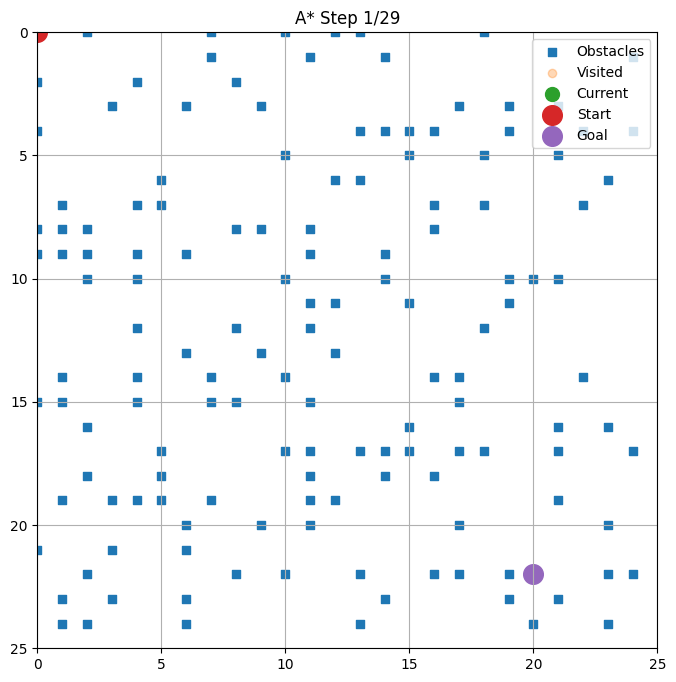

In [22]:
fig, ax = plt.subplots(figsize=(8,8))

def update(frame):
    """
    Update function for animation.

    Parameters
    ----------
    frame : int
        Current frame index in the animation

    Returns
    -------
    None
        Updates the matplotlib axis in-place
    """
    ax.clear()

    current, open_nodes, closed_nodes = steps[frame]

    # obstacles
    obstacles = np.where(grid == 1)
    ax.scatter(obstacles[1], obstacles[0], marker="s", label="Obstacles")

    # visited
    if closed_nodes:
        cy = [n[0] for n in closed_nodes]
        cx = [n[1] for n in closed_nodes]
        ax.scatter(cx, cy, alpha=0.3, label="Visited")

    # frontier
    if open_nodes:
        frontier_nodes = [n[1] for n in open_nodes]
        oy = [n[0] for n in frontier_nodes]
        ox = [n[1] for n in frontier_nodes]
        ax.scatter(ox, oy, marker="x", label="Frontier")

    # current node
    ax.scatter(current[1], current[0], s=100, label="Current")

    # start & goal
    ax.scatter(start[1], start[0], s=200, label="Start")
    ax.scatter(goal[1], goal[0], s=200, label="Goal")

    # final path
    if frame == len(steps) - 1 and path:
        px = [p[1] for p in path]
        py = [p[0] for p in path]
        ax.plot(px, py, linewidth=3, label="Path")

    ax.set_xlim(0, GRID_SIZE)
    ax.set_ylim(0, GRID_SIZE)
    ax.invert_yaxis()
    ax.grid(True)
    ax.legend(loc="upper right")
    ax.set_title(f"A* Step {frame+1}/{len(steps)}")

ani = FuncAnimation(fig, update, frames=len(steps), interval=100)

from IPython.display import HTML
HTML(ani.to_jshtml())